# Coding 3：Gamma、SQL Left Join 与波动率微笑

对应源文件：`coding_3.py`。

## 题目一：由 Delta 推导 Gamma

- Delta 是期权价格对标的价格的一阶导数。
- Gamma 是 Delta 对标的价格的一阶导数，也是期权价格对标的价格的二阶导数。
- 解析公式更精确；有限差分法更通用，但会受步长影响。

In [ ]:
from math import exp, log, sqrt
import scipy.stats as stats

def black_scholes_call(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    d1 = (log(stock_price / strike_price) + (risk_free_rate + volatility ** 2 / 2) * time_to_maturity) / (volatility * sqrt(time_to_maturity))
    d2 = d1 - volatility * sqrt(time_to_maturity)
    return stock_price * stats.norm.cdf(d1) - strike_price * exp(-risk_free_rate * time_to_maturity) * stats.norm.cdf(d2)

def delta_closed_form(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    '''看涨期权 Delta 的解析公式是 N(d1)。'''
    d1 = (log(stock_price / strike_price) + (risk_free_rate + volatility ** 2 / 2) * time_to_maturity) / (volatility * sqrt(time_to_maturity))
    return stats.norm.cdf(d1)

def gamma_closed_form(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    '''看涨/看跌欧式期权在 BSM 下 Gamma 相同。'''
    d1 = (log(stock_price / strike_price) + (risk_free_rate + volatility ** 2 / 2) * time_to_maturity) / (volatility * sqrt(time_to_maturity))
    return stats.norm.pdf(d1) / (stock_price * volatility * sqrt(time_to_maturity))

def gamma_numerical(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility, bump=1e-4):
    '''中心差分：用 C(S+h)-2C(S)+C(S-h) 近似二阶导。'''
    c_down = black_scholes_call(stock_price - bump, strike_price, time_to_maturity, risk_free_rate, volatility)
    c_mid = black_scholes_call(stock_price, strike_price, time_to_maturity, risk_free_rate, volatility)
    c_up = black_scholes_call(stock_price + bump, strike_price, time_to_maturity, risk_free_rate, volatility)
    return (c_up - 2 * c_mid + c_down) / bump ** 2

S = 40; K = 40; T = 0.5; r = 0.01; sigma = 0.2
print(round(delta_closed_form(S, K, T, r, sigma), 6))
print(round(gamma_closed_form(S, K, T, r, sigma), 6))
print(round(gamma_numerical(S, K, T, r, sigma), 6))

**结果复现：Gamma 曲线**

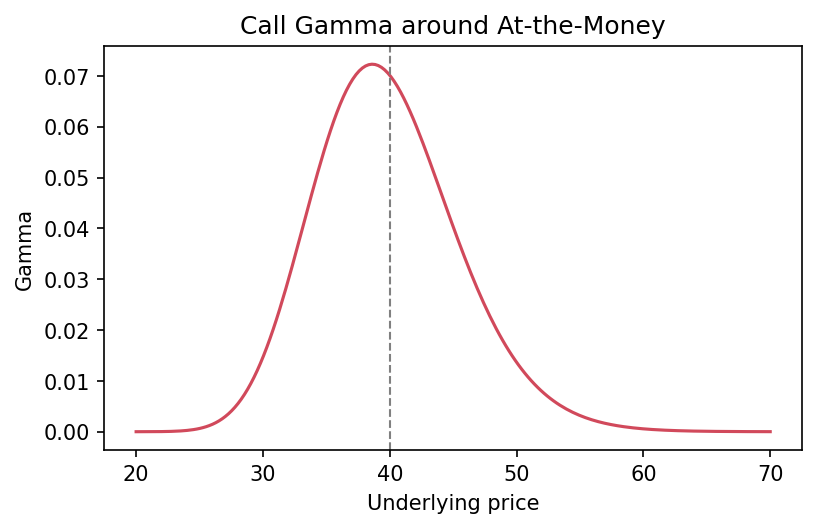

- Gamma 在平值附近通常最高，说明期权 Delta 在平值区域变化最快。
- 这也是期权风险管理中需要动态对冲的原因：标的价格一动，Delta 本身也会变。

## 题目二：SQL Left Join

- `LEFT JOIN` 保留左表所有员工。
- 没有部门编号的员工不会被丢弃，而是在部门列显示缺失。
- 这和金融数据按交易日左连接宏观变量非常相似：保留主行情表，再补充外部信息。

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()
cursor.execute('CREATE TABLE departments (dept_id INTEGER PRIMARY KEY, dept_name TEXT)')
cursor.execute('CREATE TABLE employees (id INTEGER PRIMARY KEY, name TEXT, dept_id INTEGER)')
cursor.executemany('INSERT INTO departments VALUES (?, ?)', [(10, 'Engineering'), (20, 'Sales'), (30, 'Marketing')])
cursor.executemany('INSERT INTO employees VALUES (?, ?, ?)', [(1, 'Alice', 10), (2, 'Bob', 20), (3, 'Charlie', None)])

'''LEFT JOIN：左表 employees 的 Charlie 会被保留。'''
left_join_query = '''
SELECT employees.name, departments.dept_name
FROM employees
LEFT JOIN departments ON employees.dept_id = departments.dept_id
'''
employee_department_data = pd.read_sql_query(left_join_query, conn)
conn.close()
print(employee_department_data)

**结果复现：Left Join 表**

| name | dept_name |
|---|---|
| Alice | Engineering |
| Bob | Sales |
| Charlie | NaN |

- Charlie 没有部门编号，但仍被保留，这就是 `LEFT JOIN` 和 `INNER JOIN` 最关键的区别。

## 题目三：Put 隐含波动率与 apply 方法

- 隐含波动率是给定市场期权价格后，反推出的波动率参数。
- 作业要求把 for loop 改写为 `DataFrame.apply()`，这体现了 Pandas 面向表格的写法。
- 对 put 来说，BSM 公式是 `P = K e^{-rT} N(-d2) - S N(-d1)`。

In [ ]:
from math import exp, log, sqrt
import pandas as pd
import scipy.stats as stats

def implied_volatility_put(stock_price, strike_price, time_to_maturity, risk_free_rate, market_put_price):
    '''暴力搜索使 BSM put 价格最接近市场价格的 volatility。'''
    implied_vol = 1.0
    min_error = float('inf')
    for i in range(1, 10000):
        volatility = 0.0001 * i
        d1 = (log(stock_price / strike_price) + (risk_free_rate + volatility ** 2 / 2) * time_to_maturity) / (volatility * sqrt(time_to_maturity))
        d2 = d1 - volatility * sqrt(time_to_maturity)
        put_price = strike_price * exp(-risk_free_rate * time_to_maturity) * stats.norm.cdf(-d2) - stock_price * stats.norm.cdf(-d1)
        error = abs(put_price - market_put_price)
        if error < min_error:
            min_error = error
            implied_vol = volatility
    return implied_vol

option_chain = pd.DataFrame({'Bid': [2.5, 3.0, 3.5], 'Ask': [2.7, 3.2, 3.8], 'Strike': [40, 45, 50]})
option_chain['Mid_Price'] = (option_chain['Bid'] + option_chain['Ask']) / 2
clean_options = option_chain[option_chain['Mid_Price'] > 0].copy()

S = 40; T = 0.5; r = 0.01
'''axis=1 表示逐行计算，每行传入一个行对象。'''
clean_options['Implied_Vol'] = clean_options.apply(
    lambda row: implied_volatility_put(S, row['Strike'], T, r, row['Mid_Price']),
    axis=1,
)
print(clean_options)

**结果复现：波动率微笑**

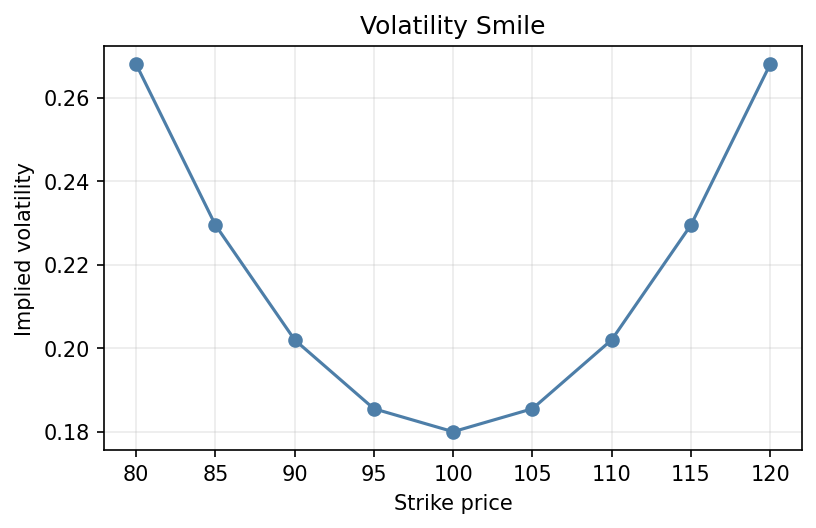

- 用 `apply()` 得到每个行权价对应的隐含波动率后，就可以画出波动率微笑。
- 如果微笑很明显，说明市场对不同行权价的尾部风险定价不同。